<a href="https://colab.research.google.com/github/vishalraine123-rgb/CN7030-2526-T3-Machine-Learning-on-Big-Data-OC-/blob/main/week8_BankNote_Authentication_pp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name :Vishal Kumar
Student ID : 3262025

In [1]:
# ==========================================================
# 1. Install PySpark
# ==========================================================
# Run this cell once in Google Colab or a fresh environment.

!pip install -q pyspark

In [2]:
# ==========================================================
# 2. Import required libraries
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, isnan
from pyspark.ml.feature import VectorAssembler, StandardScaler

from sklearn.decomposition import PCA
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ==========================================================
# 3. Create a Spark session
# ==========================================================

spark = (
    SparkSession.builder
    .appName("Perceptron_MSc_Guided_Lab")
    .getOrCreate()
)

print("Spark version:", spark.version)

Spark version: 4.0.3


In [39]:
# ==========================================================
# 4. Load the dataset
# ==========================================================

url = (
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/banknote_authentication.csv"
)

columns = [
    "Variance",
    "Skewness",
    "Curtosis",
    "Entropy",
    "Class",
]

pdf = pd.read_csv(url, header=None, names=columns)

# Keep an explicit integer target.
pdf["Class"] = pdf["Class"].astype(int)

df = spark.createDataFrame(pdf)

print("Dataset loaded successfully.")
df.show(5)

Dataset loaded successfully.
+--------+--------+--------+--------+-----+
|Variance|Skewness|Curtosis| Entropy|Class|
+--------+--------+--------+--------+-----+
|  3.6216|  8.6661| -2.8073|-0.44699|    0|
|  4.5459|  8.1674| -2.4586| -1.4621|    0|
|   3.866| -2.6383|  1.9242| 0.10645|    0|
|  3.4566|  9.5228| -4.0112| -3.5944|    0|
| 0.32924| -4.4552|  4.5718| -0.9888|    0|
+--------+--------+--------+--------+-----+
only showing top 5 rows


In [40]:
# ==========================================================
# 5. Inspect the dataset
# ==========================================================

print("Schema")
df.printSchema()

row_count = df.count()
column_count = len(df.columns)

print("\nDimensions")
print("Rows   :", row_count)
print("Columns:", column_count)

print("\nSummary statistics")
df.describe().show()

print("\nClass distribution")
df.groupBy("Class").count().orderBy("Class").show()

print("\nMissing values")
df.select([
    count(
        when(col(c).isNull() | isnan(c), c)
    ).alias(c)
    for c in df.columns
]).show()

Schema
root
 |-- Variance: double (nullable = true)
 |-- Skewness: double (nullable = true)
 |-- Curtosis: double (nullable = true)
 |-- Entropy: double (nullable = true)
 |-- Class: long (nullable = true)


Dimensions
Rows   : 1372
Columns: 5

Summary statistics
+-------+------------------+------------------+------------------+-------------------+-------------------+
|summary|          Variance|          Skewness|          Curtosis|            Entropy|              Class|
+-------+------------------+------------------+------------------+-------------------+-------------------+
|  count|              1372|              1372|              1372|               1372|               1372|
|   mean|0.4337352570699717|1.9223531206393598|1.3976271172667647|-1.1916565200437317| 0.4446064139941691|
| stddev| 2.842762586278561| 5.869046743695514| 4.310030090106595| 2.1010131373596095|0.49710327012566086|
|    min|           -7.0421|          -13.7731|           -5.2861|            -8.5482|        

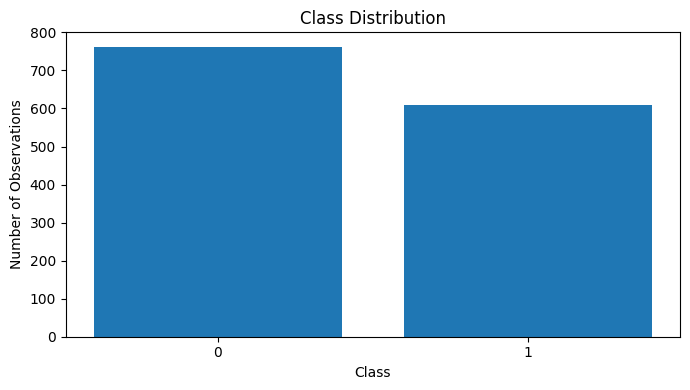

Class
0    762
1    610
Name: count, dtype: int64


In [41]:
# ==========================================================
# 6. Visual 1: Class distribution
# ==========================================================

class_counts = pdf["Class"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

print(class_counts)

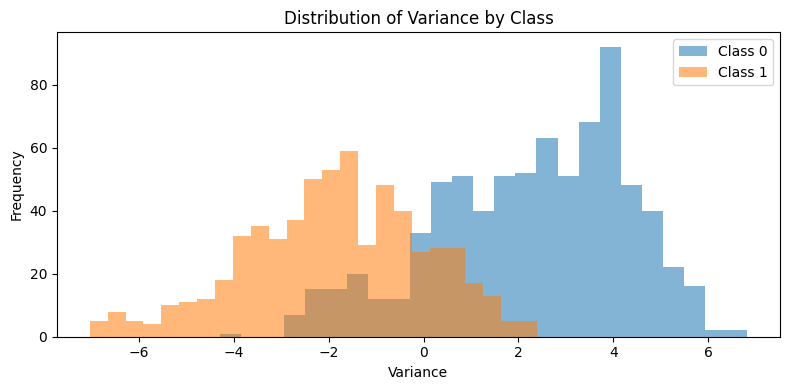

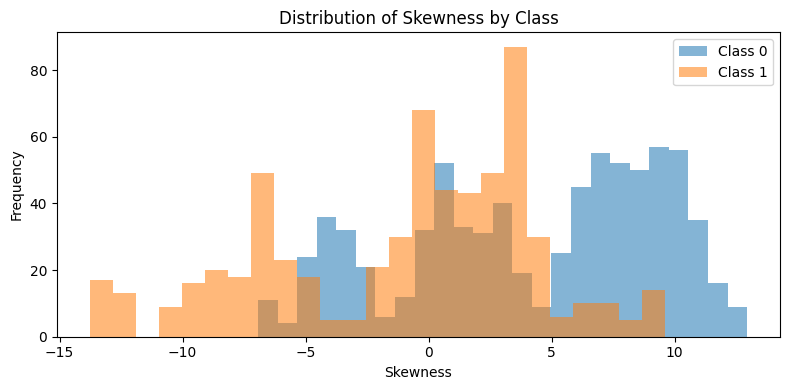

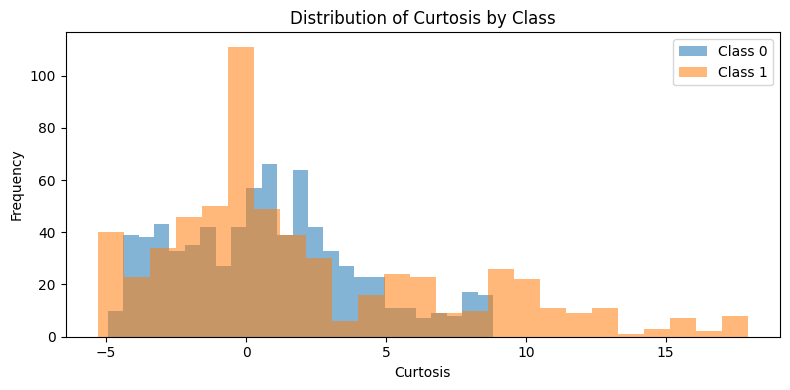

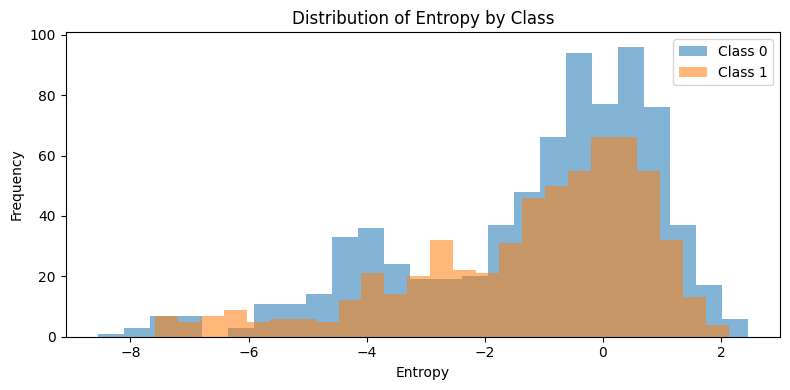

In [42]:
# ==========================================================
# 7. Visuals 2–5: Feature distributions by class
# ==========================================================
# A separate figure is produced for each feature.

feature_columns = [
    "Variance",
    "Skewness",
    "Curtosis",
    "Entropy",
]

for feature in feature_columns:
    plt.figure(figsize=(8, 4))

    for class_value in sorted(pdf["Class"].unique()):
        values = pdf.loc[pdf["Class"] == class_value, feature]
        plt.hist(
            values,
            bins=25,
            alpha=0.55,
            label=f"Class {class_value}",
        )

    plt.title(f"Distribution of {feature} by Class")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

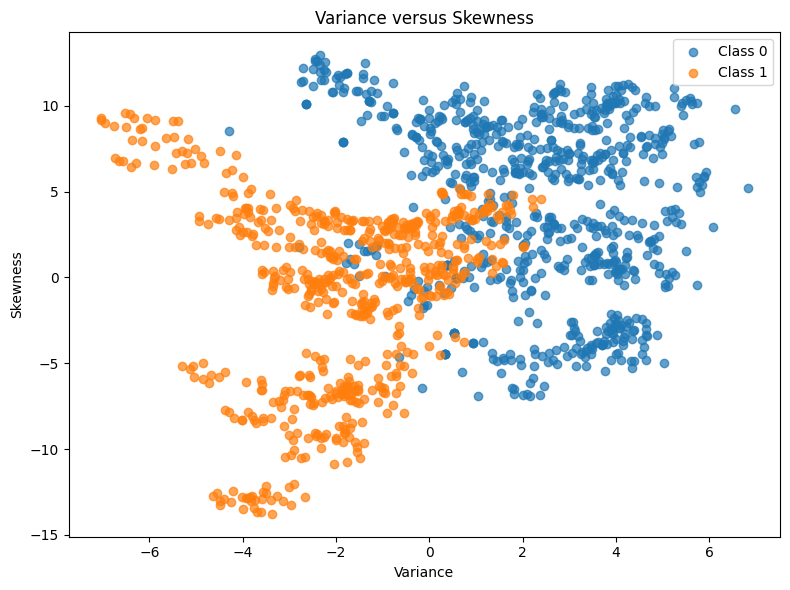

This two-dimensional view may hide overlap or separation that exists in the other features.


In [44]:
# ==========================================================
# 8. Visual 6: Two-feature scatter plot
# ==========================================================

plt.figure(figsize=(8, 6))

for class_value in sorted(pdf["Class"].unique()):
    subset = pdf[pdf["Class"] == class_value]

    plt.scatter(
        subset["Variance"],
        subset["Skewness"],
        label=f"Class {class_value}",
        alpha=0.7,
    )

plt.title("Variance versus Skewness")
plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "This two-dimensional view may hide overlap or separation "
    "that exists in the other features."
)

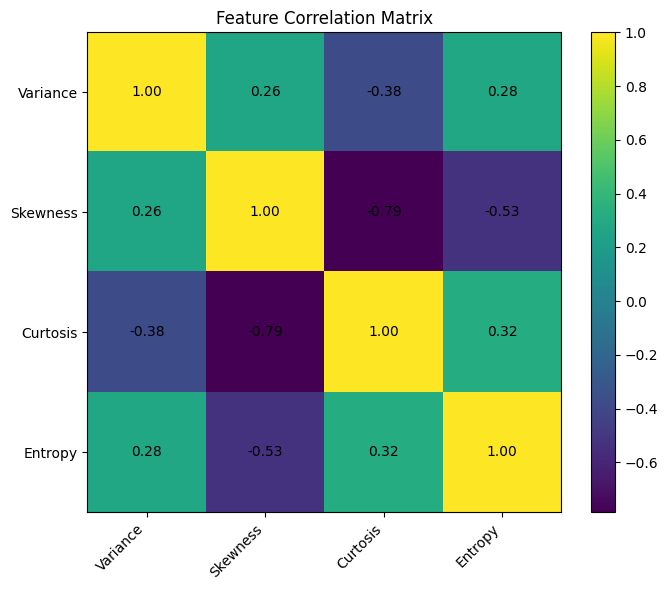

In [45]:
# ==========================================================
# 9. Visual 7: Correlation matrix
# ==========================================================

correlation_matrix = pdf[feature_columns].corr()

plt.figure(figsize=(7, 6))
image = plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(image)

tick_positions = np.arange(len(feature_columns))
plt.xticks(tick_positions, feature_columns, rotation=45, ha="right")
plt.yticks(tick_positions, feature_columns)

for row in range(correlation_matrix.shape[0]):
    for column in range(correlation_matrix.shape[1]):
        plt.text(
            column,
            row,
            f"{correlation_matrix.iloc[row, column]:.2f}",
            ha="center",
            va="center",
        )

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [46]:
# ==========================================================
# 10. Assemble the raw feature vector
# ==========================================================

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features",
)

assembled_data = assembler.transform(df)

assembled_data.select("features", "Class").show(5, truncate=False)

+--------------------------------+-----+
|features                        |Class|
+--------------------------------+-----+
|[3.6216,8.6661,-2.8073,-0.44699]|0    |
|[4.5459,8.1674,-2.4586,-1.4621] |0    |
|[3.866,-2.6383,1.9242,0.10645]  |0    |
|[3.4566,9.5228,-4.0112,-3.5944] |0    |
|[0.32924,-4.4552,4.5718,-0.9888]|0    |
+--------------------------------+-----+
only showing top 5 rows


In [47]:
# ==========================================================
# 11. Split BEFORE fitting the scaler
# ==========================================================

train_raw, test_raw = assembled_data.randomSplit(
    [0.80, 0.20],
    seed=RANDOM_STATE,
)

# Cache because these frames are used repeatedly.
train_raw = train_raw.cache()
test_raw = test_raw.cache()

train_count = train_raw.count()
test_count = test_raw.count()

print("Training observations:", train_count)
print("Test observations    :", test_count)
print("Total                :", train_count + test_count)

Training observations: 1117
Test observations    : 255
Total                : 1372


In [48]:
# ==========================================================
# 12. Fit the scaler only on the training data
# ==========================================================

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaledFeatures",
    withMean=True,
    withStd=True,
)

scaler_model = scaler.fit(train_raw)

train_df = scaler_model.transform(train_raw)
test_df = scaler_model.transform(test_raw)

print("Training data after scaling")
train_df.select("scaledFeatures", "Class").show(5, truncate=False)

Training data after scaling
+---------------------------------------------------------------------------------+-----+
|scaledFeatures                                                                   |Class|
+---------------------------------------------------------------------------------+-----+
|[-1.679416310648687,1.1143482574582444,0.4046039774061341,0.12607497976257642]   |0    |
|[-1.153782605222557,-0.036374792252223606,1.253100395808368,0.3735422528955864]  |0    |
|[-1.1212492377070553,1.7408530289672768,-0.17000244515275867,-3.5252729627191273]|0    |
|[-1.1033119215633735,1.3894989244556806,-0.6384464817132329,-2.052880005742022]  |0    |
|[-1.1033119215633735,1.3894989244556806,-0.6384464817132329,-2.052880005742022]  |0    |
+---------------------------------------------------------------------------------+-----+
only showing top 5 rows


In [16]:
# ==========================================================
# 13. Inspect the learned scaling parameters
# ==========================================================

scaling_parameters = pd.DataFrame({
    "Feature": feature_columns,
    "Training Mean": scaler_model.mean.toArray(),
    "Training Standard Deviation": scaler_model.std.toArray(),
})

print(scaling_parameters.to_string(index=False))

 Feature  Training Mean  Training Standard Deviation
Variance       0.489075                     2.843235
Skewness       1.986770                     5.865877
Curtosis       1.405189                     4.285699
 Entropy      -1.179904                     2.090135


In [49]:
# ==========================================================
# 14. Collect the small teaching dataset into NumPy arrays
# ==========================================================
# collect() moves data to the Spark driver.
# This is acceptable here because the dataset is small.
# It would not be appropriate for a genuinely large dataset.

def spark_frame_to_numpy(frame):
    rows = frame.select("scaledFeatures", "Class").collect()

    X = np.array([
        row["scaledFeatures"].toArray()
        for row in rows
    ])

    # Convert original labels 0/1 into perceptron labels -1/+1.
    y = np.array([
        1 if int(row["Class"]) == 1 else -1
        for row in rows
    ])

    return X, y


X_train, y_train = spark_frame_to_numpy(train_df)
X_test, y_test = spark_frame_to_numpy(test_df)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Training labels:", np.unique(y_train, return_counts=True))
print("Test labels    :", np.unique(y_test, return_counts=True))

X_train shape: (1117, 4)
X_test shape : (255, 4)
Training labels: (array([-1,  1]), array([637, 480]))
Test labels    : (array([-1,  1]), array([125, 130]))


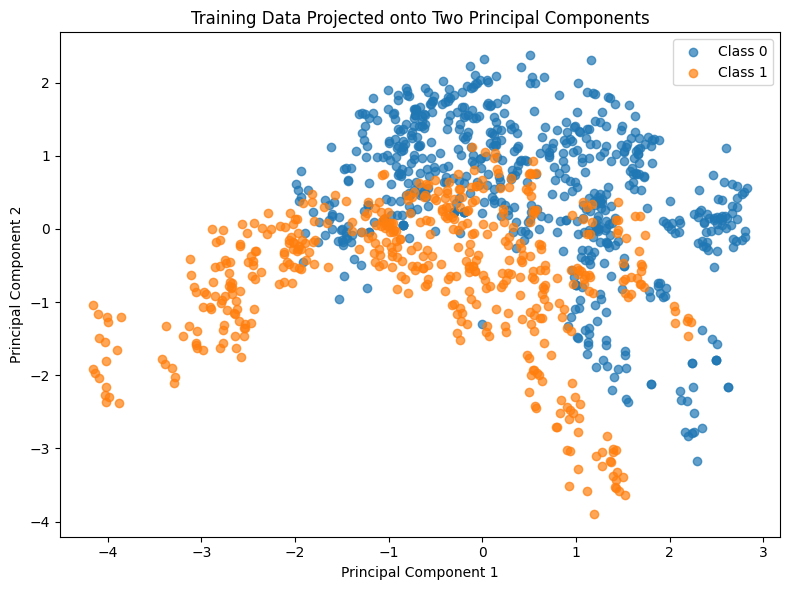

Explained variance: [0.544  0.3248]


In [50]:
# ==========================================================
# 15. Visual 8: PCA projection of the scaled training data
# ==========================================================
# PCA is used only to visualise the four-dimensional data in two dimensions.

pca_for_view = PCA(n_components=2)
X_train_pca = pca_for_view.fit_transform(X_train)

plt.figure(figsize=(8, 6))

for label in (-1, 1):
    mask = y_train == label
    plt.scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        label=f"Class {0 if label == -1 else 1}",
        alpha=0.7,
    )

plt.title("Training Data Projected onto Two Principal Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Explained variance:",
    np.round(pca_for_view.explained_variance_ratio_, 4),
)

In [51]:
# ==========================================================
# 16. Manual perceptron implementation
# ==========================================================

class ManualPerceptron:
    def __init__(
        self,
        learning_rate=0.01,
        epochs=100,
        shuffle=True,
        random_state=42,
    ):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.shuffle = shuffle
        self.random_state = random_state

    @staticmethod
    def activation(score):
        return np.where(score >= 0, 1, -1)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)

        if set(np.unique(y)) - {-1, 1}:
            raise ValueError("The perceptron labels must be -1 or +1.")

        rng = np.random.default_rng(self.random_state)

        self.weights_ = np.zeros(X.shape[1], dtype=float)
        self.bias_ = 0.0

        self.errors_per_epoch_ = []
        self.weights_history_ = []
        self.bias_history_ = []

        self.best_errors_ = np.inf
        self.best_weights_ = self.weights_.copy()
        self.best_bias_ = self.bias_
        self.best_epoch_ = 0
        self.converged_ = False

        for epoch in range(self.epochs):
            indices = np.arange(X.shape[0])

            if self.shuffle:
                rng.shuffle(indices)

            errors = 0

            for index in indices:
                sample = X[index]
                target = y[index]

                score = np.dot(sample, self.weights_) + self.bias_
                prediction = 1 if score >= 0 else -1

                if prediction != target:
                    update = self.learning_rate * target
                    self.weights_ += update * sample
                    self.bias_ += update
                    errors += 1

            self.errors_per_epoch_.append(errors)
            self.weights_history_.append(self.weights_.copy())
            self.bias_history_.append(self.bias_)

            if errors < self.best_errors_:
                self.best_errors_ = errors
                self.best_weights_ = self.weights_.copy()
                self.best_bias_ = self.bias_
                self.best_epoch_ = epoch + 1

            if errors == 0:
                self.converged_ = True
                break

        self.weights_history_ = np.asarray(self.weights_history_)
        self.bias_history_ = np.asarray(self.bias_history_)

        return self

    def decision_function(self, X, use_pocket=False):
        X = np.asarray(X, dtype=float)

        if use_pocket:
            weights = self.best_weights_
            bias = self.best_bias_
        else:
            weights = self.weights_
            bias = self.bias_

        return X @ weights + bias

    def predict(self, X, use_pocket=False):
        scores = self.decision_function(X, use_pocket=use_pocket)
        return self.activation(scores)

In [52]:
# ==========================================================
# 17. Train the manual perceptron
# ==========================================================

model = ManualPerceptron(
    learning_rate=0.01,
    epochs=100,
    shuffle=True,
    random_state=RANDOM_STATE,
)

model.fit(X_train, y_train)

print("Epochs completed       :", len(model.errors_per_epoch_))
print("Converged              :", model.converged_)
print("Best training errors   :", model.best_errors_)
print("Best epoch             :", model.best_epoch_)
print("Final weights          :", np.round(model.weights_, 4))
print("Final bias             :", round(model.bias_, 4))
print("Pocket weights         :", np.round(model.best_weights_, 4))
print("Pocket bias            :", round(model.best_bias_, 4))

if not model.converged_:
    print(
        "\nThe training errors did not reach zero. "
        "This is consistent with non-separable or noisy data."
    )

Epochs completed       : 100
Converged              : False
Best training errors   : 8
Best epoch             : 22
Final weights          : [-0.2465 -0.2739 -0.245   0.0047]
Final bias             : -0.15
Pocket weights         : [-0.176  -0.1744 -0.1616 -0.0099]
Pocket bias            : -0.09

The training errors did not reach zero. This is consistent with non-separable or noisy data.


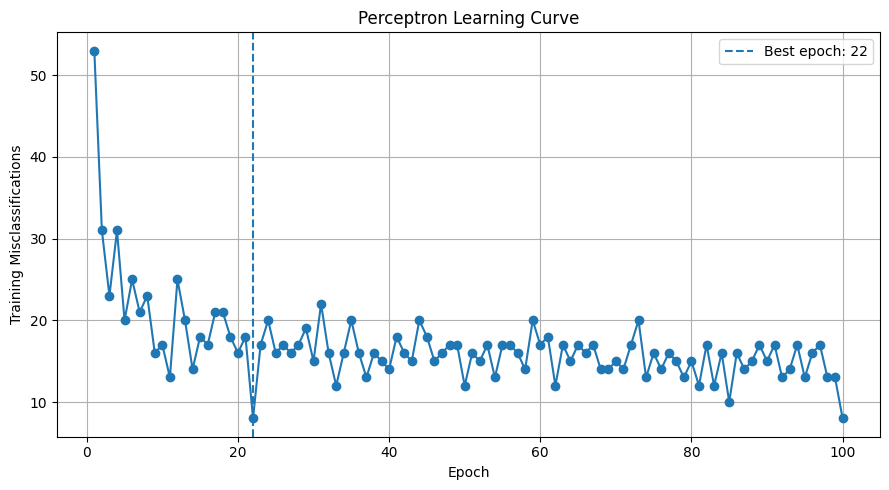

In [53]:
# ==========================================================
# 18. Visual 9: Misclassifications per epoch
# ==========================================================

epochs_completed = np.arange(1, len(model.errors_per_epoch_) + 1)

plt.figure(figsize=(9, 5))
plt.plot(
    epochs_completed,
    model.errors_per_epoch_,
    marker="o",
)
plt.axvline(
    model.best_epoch_,
    linestyle="--",
    label=f"Best epoch: {model.best_epoch_}",
)
plt.title("Perceptron Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("Training Misclassifications")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

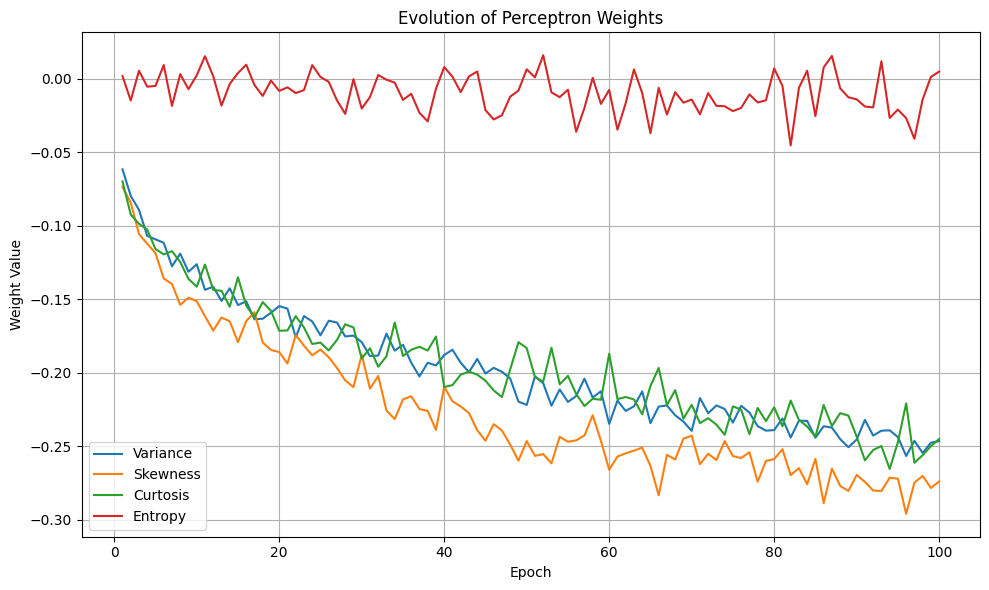

In [54]:
# ==========================================================
# 19. Visual 10: Weight trajectories
# ==========================================================

plt.figure(figsize=(10, 6))

for feature_index, feature_name in enumerate(feature_columns):
    plt.plot(
        epochs_completed,
        model.weights_history_[:, feature_index],
        label=feature_name,
    )

plt.title("Evolution of Perceptron Weights")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

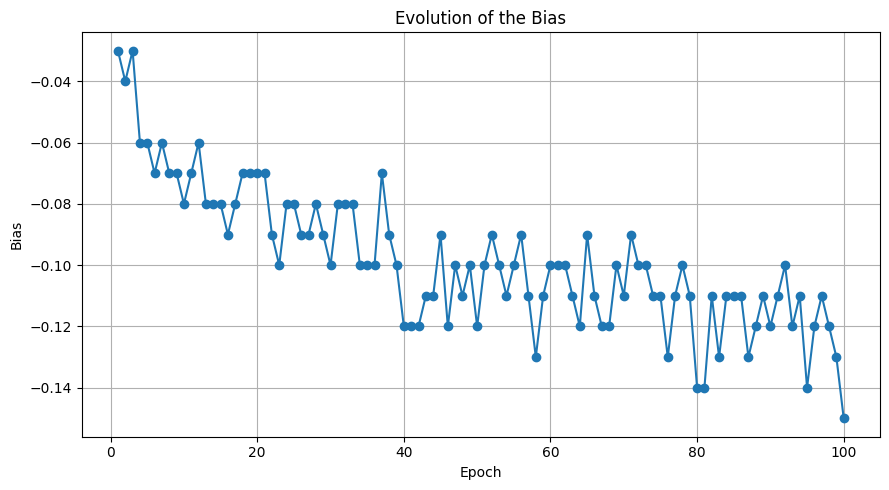

In [55]:
# ==========================================================
# 20. Visual 11: Bias trajectory
# ==========================================================

plt.figure(figsize=(9, 5))
plt.plot(
    epochs_completed,
    model.bias_history_,
    marker="o",
)
plt.title("Evolution of the Bias")
plt.xlabel("Epoch")
plt.ylabel("Bias")
plt.grid(True)
plt.tight_layout()
plt.show()

In [56]:
# ==========================================================
# 21. Generate test predictions
# ==========================================================

y_pred_pocket = model.predict(X_test, use_pocket=True)
y_pred_final = model.predict(X_test, use_pocket=False)

print("First 15 test predictions")
prediction_preview = pd.DataFrame({
    "Actual": y_test[:15],
    "Pocket prediction": y_pred_pocket[:15],
    "Final-epoch prediction": y_pred_final[:15],
})

print(prediction_preview.to_string(index=False))

First 15 test predictions
 Actual  Pocket prediction  Final-epoch prediction
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1
     -1                 -1                      -1


In [57]:
# ==========================================================
# 22. Calculate classification metrics
# ==========================================================

def metric_summary(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0,
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0,
        ),
    }


pocket_metrics = metric_summary(y_test, y_pred_pocket)
final_metrics = metric_summary(y_test, y_pred_final)

metrics_table = pd.DataFrame({
    "Pocket model": pocket_metrics,
    "Final-epoch model": final_metrics,
}).T

print(metrics_table.round(4).to_string())

                   Accuracy  Precision  Recall      F1
Pocket model         0.9922        1.0  0.9846  0.9922
Final-epoch model    0.9922        1.0  0.9846  0.9922


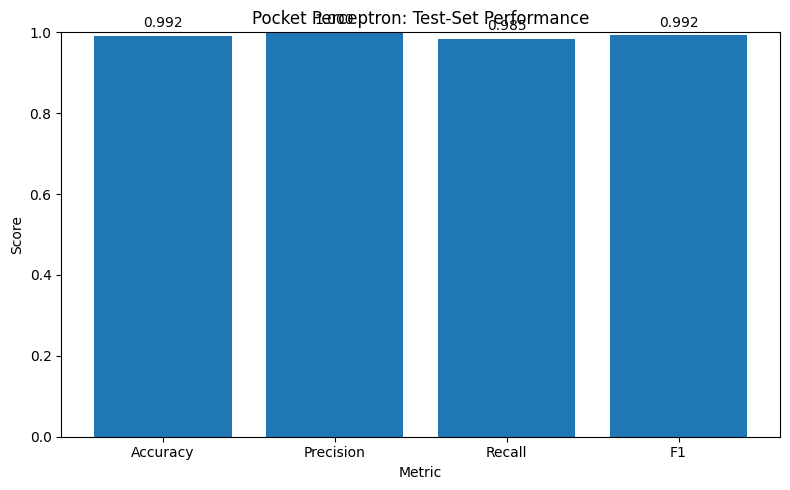

In [58]:
# ==========================================================
# 23. Visual 12: Performance metrics
# ==========================================================

metric_names = list(pocket_metrics.keys())
metric_values = list(pocket_metrics.values())

plt.figure(figsize=(8, 5))
plt.bar(metric_names, metric_values)
plt.ylim(0, 1)
plt.title("Pocket Perceptron: Test-Set Performance")
plt.xlabel("Metric")
plt.ylabel("Score")

for index, value in enumerate(metric_values):
    plt.text(index, value + 0.02, f"{value:.3f}", ha="center")

plt.tight_layout()
plt.show()

In [59]:
# ==========================================================
# 24. Classification report
# ==========================================================

print(
    classification_report(
        y_test,
        y_pred_pocket,
        labels=[-1, 1],
        target_names=["Class 0", "Class 1"],
        zero_division=0,
    )
)

              precision    recall  f1-score   support

     Class 0       0.98      1.00      0.99       125
     Class 1       1.00      0.98      0.99       130

    accuracy                           0.99       255
   macro avg       0.99      0.99      0.99       255
weighted avg       0.99      0.99      0.99       255



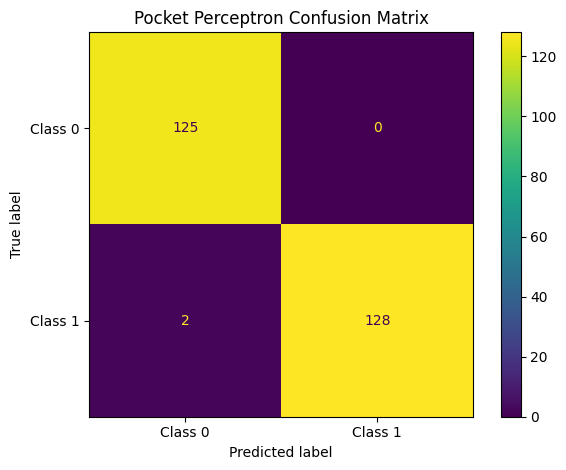

In [60]:
# ==========================================================
# 25. Visual 13: Confusion matrix
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred_pocket,
    labels=[-1, 1],
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1"],
)

display.plot()
plt.title("Pocket Perceptron Confusion Matrix")
plt.tight_layout()
plt.show()

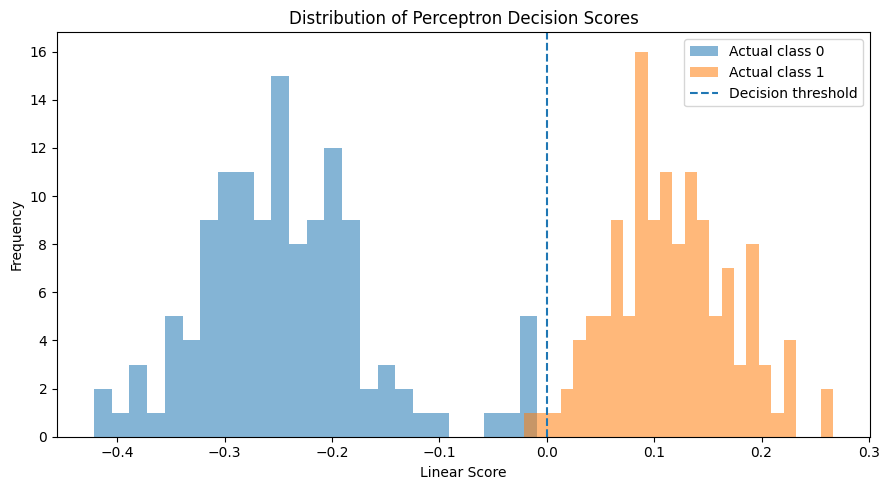

In [61]:
# ==========================================================
# 26. Visual 14: Decision-score distributions
# ==========================================================
# Distance from zero indicates the model's signed confidence,
# but it is not a calibrated probability.

test_scores = model.decision_function(
    X_test,
    use_pocket=True,
)

plt.figure(figsize=(9, 5))

for label in (-1, 1):
    plt.hist(
        test_scores[y_test == label],
        bins=25,
        alpha=0.55,
        label=f"Actual class {0 if label == -1 else 1}",
    )

plt.axvline(0, linestyle="--", label="Decision threshold")
plt.title("Distribution of Perceptron Decision Scores")
plt.xlabel("Linear Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

In [62]:
# ==========================================================
# 27. Inspect misclassified test observations
# ==========================================================

misclassified_mask = y_pred_pocket != y_test
misclassified_indices = np.where(misclassified_mask)[0]

misclassified_table = pd.DataFrame(
    X_test[misclassified_mask],
    columns=[f"Scaled {name}" for name in feature_columns],
)

misclassified_table["Actual"] = y_test[misclassified_mask]
misclassified_table["Predicted"] = y_pred_pocket[misclassified_mask]
misclassified_table["Score"] = test_scores[misclassified_mask]

print("Number of misclassified test observations:", len(misclassified_table))
print(misclassified_table.head(15).round(4).to_string(index=False))

Number of misclassified test observations: 2
 Scaled Variance  Scaled Skewness  Scaled Curtosis  Scaled Entropy  Actual  Predicted   Score
         -1.3606          -2.6867           3.8552         -0.4078       1         -1 -0.0008
          0.5376          -0.0321          -1.0181          0.6649       1         -1 -0.0211


# 27.5 Visual 14.5: Misclassified test observations in PCA space

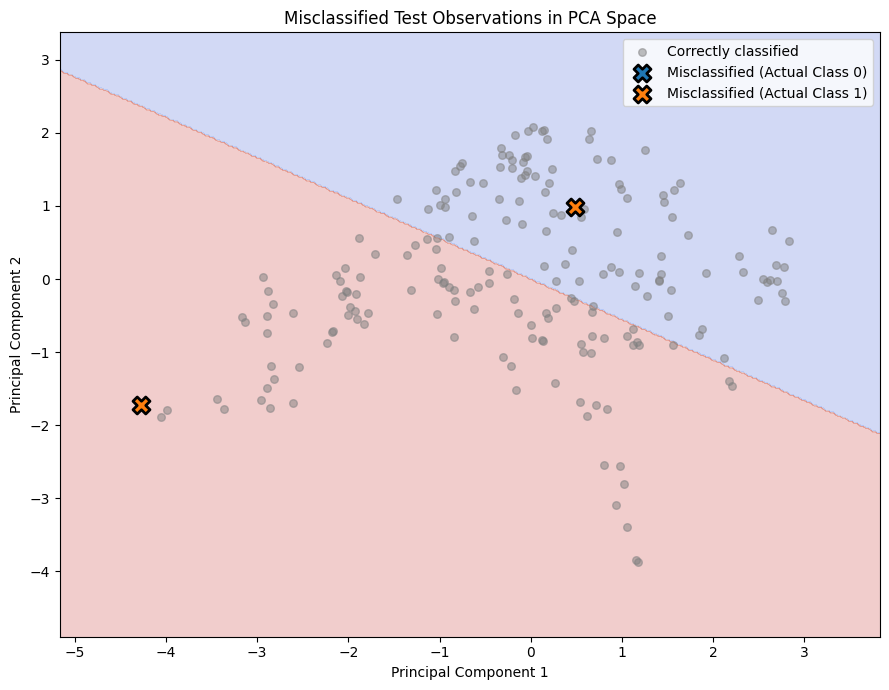

In [76]:
plt.figure(figsize=(9, 7))

# Plot decision regions as background
plt.contourf(
    grid_x,
    grid_y,
    grid_predictions,
    alpha=0.25,
    cmap='coolwarm', # Use a distinct colormap for decision regions
)

# Plot all test points, correctly classified in gray
plt.scatter(
    X_test_2d[correct_mask, 0],
    X_test_2d[correct_mask, 1],
    color='gray',
    alpha=0.5,
    label='Correctly classified',
    s=30
)

# Plot misclassified points
misclassified_pca_points = X_test_2d[misclassified_mask]
misclassified_actual_labels = y_test[misclassified_mask]

for label in (-1, 1):
    mask = misclassified_actual_labels == label
    plt.scatter(
        misclassified_pca_points[mask, 0],
        misclassified_pca_points[mask, 1],
        marker='X',
        s=150, # Make misclassified points larger
        linewidth=2,
        edgecolor='black', # Add an edge for better visibility
        label=f"Misclassified (Actual Class {0 if label == -1 else 1})",
        zorder=5, # Ensure misclassified points are on top
    )

plt.title("Misclassified Test Observations in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

In [63]:
# ==========================================================
# 28. Prepare a two-dimensional PCA representation
# ==========================================================

pca_2d = PCA(n_components=2)

X_train_2d = pca_2d.fit_transform(X_train)
X_test_2d = pca_2d.transform(X_test)

visual_model = ManualPerceptron(
    learning_rate=0.01,
    epochs=100,
    shuffle=True,
    random_state=RANDOM_STATE,
)

visual_model.fit(X_train_2d, y_train)

print("2D model converged:", visual_model.converged_)
print("2D best training errors:", visual_model.best_errors_)

2D model converged: False
2D best training errors: 282


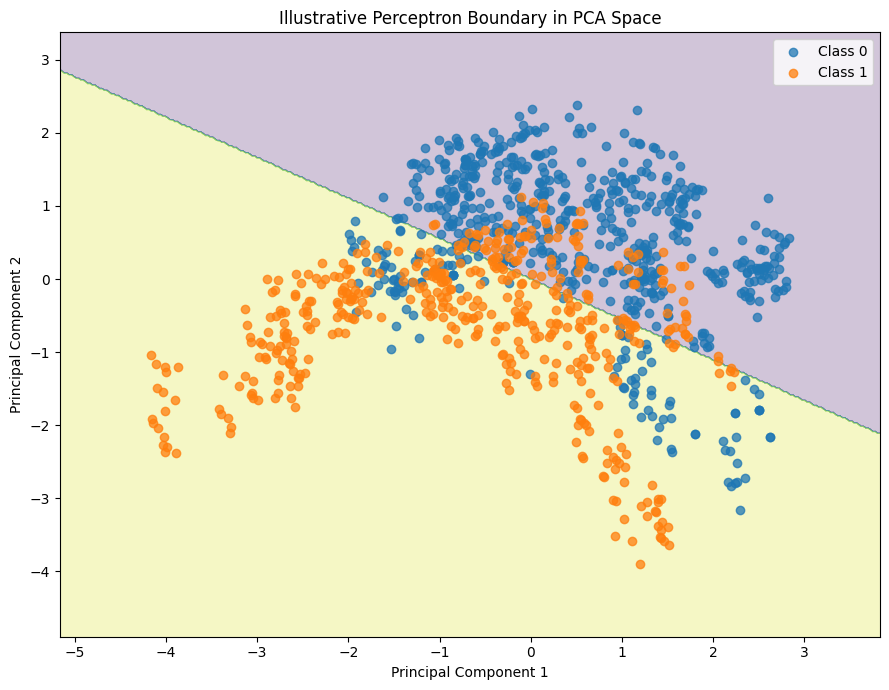

In [64]:
# ==========================================================
# 29. Visual 15: Two-dimensional decision regions
# ==========================================================

x_min = X_train_2d[:, 0].min() - 1
x_max = X_train_2d[:, 0].max() + 1
y_min = X_train_2d[:, 1].min() - 1
y_max = X_train_2d[:, 1].max() + 1

grid_x, grid_y = np.meshgrid(
    np.linspace(x_min, x_max, 350),
    np.linspace(y_min, y_max, 350),
)

grid_points = np.column_stack([
    grid_x.ravel(),
    grid_y.ravel(),
])

grid_predictions = visual_model.predict(
    grid_points,
    use_pocket=True,
).reshape(grid_x.shape)

plt.figure(figsize=(9, 7))
plt.contourf(
    grid_x,
    grid_y,
    grid_predictions,
    alpha=0.25,
)

for label in (-1, 1):
    mask = y_train == label
    plt.scatter(
        X_train_2d[mask, 0],
        X_train_2d[mask, 1],
        label=f"Class {0 if label == -1 else 1}",
        alpha=0.75,
    )

plt.title("Illustrative Perceptron Boundary in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

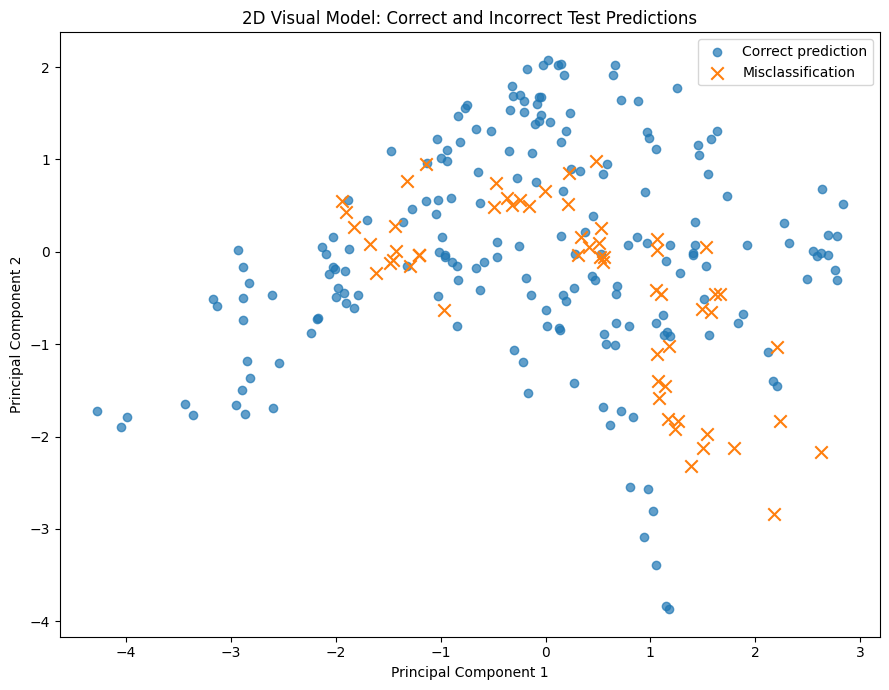

In [65]:
# ==========================================================
# 30. Visual 16: Correct and incorrect test predictions in PCA space
# ==========================================================

visual_test_predictions = visual_model.predict(
    X_test_2d,
    use_pocket=True,
)

correct_mask = visual_test_predictions == y_test

plt.figure(figsize=(9, 7))

plt.scatter(
    X_test_2d[correct_mask, 0],
    X_test_2d[correct_mask, 1],
    label="Correct prediction",
    alpha=0.7,
)

plt.scatter(
    X_test_2d[~correct_mask, 0],
    X_test_2d[~correct_mask, 1],
    marker="x",
    s=80,
    label="Misclassification",
)

plt.title("2D Visual Model: Correct and Incorrect Test Predictions")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

In [66]:
# ==========================================================
# 31. Compare with scikit-learn's perceptron
# ==========================================================

sk_model = SklearnPerceptron(
    eta0=0.01,
    max_iter=100,
    tol=None,
    shuffle=True,
    random_state=RANDOM_STATE,
    fit_intercept=True,
)

sk_model.fit(X_train, y_train)
sk_predictions = sk_model.predict(X_test)

comparison = pd.DataFrame({
    "Manual pocket": pocket_metrics,
    "Manual final epoch": final_metrics,
    "scikit-learn": metric_summary(y_test, sk_predictions),
}).T

print(comparison.round(4).to_string())

                    Accuracy  Precision  Recall      F1
Manual pocket         0.9922     1.0000  0.9846  0.9922
Manual final epoch    0.9922     1.0000  0.9846  0.9922
scikit-learn          0.9804     0.9771  0.9846  0.9808


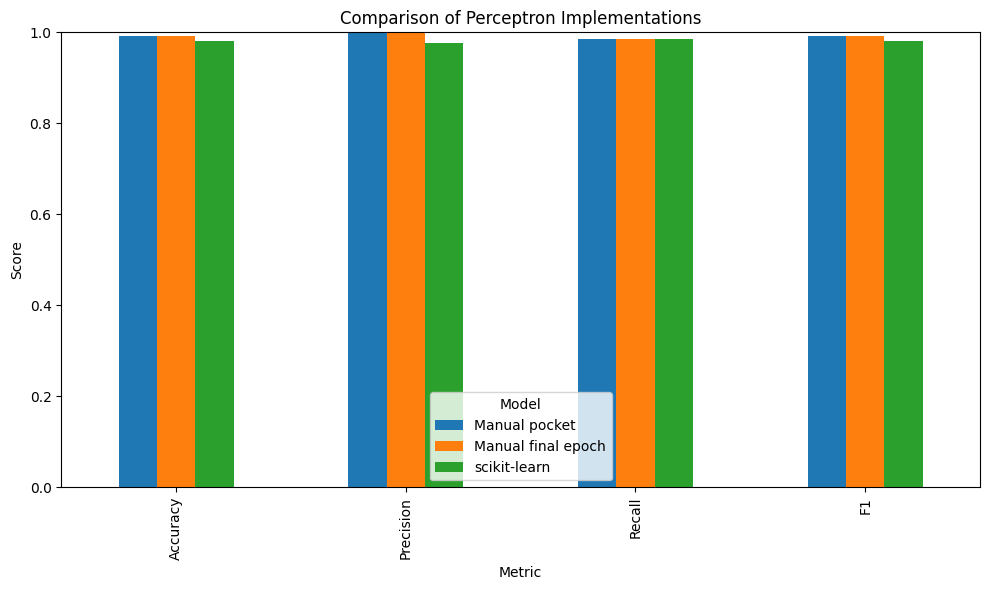

In [67]:
# ==========================================================
# 32. Visual 17: Model comparison
# ==========================================================

comparison.T.plot(kind="bar", figsize=(10, 6))
plt.ylim(0, 1)
plt.title("Comparison of Perceptron Implementations")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

In [68]:
# ==========================================================
# 33. Reproducibility summary
# ==========================================================

print("=" * 72)
print("PERCEPTRON MSc GUIDED LAB COMPLETED")
print("=" * 72)
print("Random seed                 :", RANDOM_STATE)
print("Training observations       :", len(X_train))
print("Test observations           :", len(X_test))
print("Epochs completed            :", len(model.errors_per_epoch_))
print("Classical model converged    :", model.converged_)
print("Best training error count   :", model.best_errors_)
print("Pocket-model test accuracy  :", round(pocket_metrics["Accuracy"], 4))
print("=" * 72)

PERCEPTRON MSc GUIDED LAB COMPLETED
Random seed                 : 42
Training observations       : 1117
Test observations           : 255
Epochs completed            : 100
Classical model converged    : False
Best training error count   : 8
Pocket-model test accuracy  : 0.9922


--------Multilayer Perceptron Classifier------

In [69]:
# ==========================================================
# 34. Train scikit-learn's MLPClassifier
# ==========================================================

from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=100,
    random_state=RANDOM_STATE,
    tol=1e-4,
    verbose=False,
)

mlp_model.fit(X_train, y_train)

print("MLPClassifier training complete.")

MLPClassifier training complete.


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


In [70]:
# ==========================================================
# 35. Generate test predictions for MLPClassifier
# ==========================================================

mlp_predictions = mlp_model.predict(X_test)

print("First 15 MLPClassifier test predictions")
prediction_preview_mlp = pd.DataFrame({
    "Actual": y_test[:15],
    "MLP prediction": mlp_predictions[:15],
})
print(prediction_preview_mlp.to_string(index=False))

First 15 MLPClassifier test predictions
 Actual  MLP prediction
     -1              -1
     -1              -1
     -1              -1
     -1              -1
     -1              -1
     -1              -1
     -1              -1
     -1              -1
     -1              -1
     -1              -1
     -1              -1
     -1              -1
     -1              -1
     -1              -1
     -1              -1


In [71]:
# ==========================================================
# 36. Calculate classification metrics for MLPClassifier
# ==========================================================

mlp_metrics = metric_summary(y_test, mlp_predictions)

print("MLPClassifier metrics:")
print(pd.DataFrame([mlp_metrics]).round(4).to_string(index=False))

MLPClassifier metrics:
 Accuracy  Precision  Recall  F1
      1.0        1.0     1.0 1.0


In [72]:
# ==========================================================
# 37. Classification report for MLPClassifier
# ==========================================================

print(
    classification_report(
        y_test,
        mlp_predictions,
        labels=[-1, 1],
        target_names=["Class 0", "Class 1"],
        zero_division=0,
    )
)

              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00       125
     Class 1       1.00      1.00      1.00       130

    accuracy                           1.00       255
   macro avg       1.00      1.00      1.00       255
weighted avg       1.00      1.00      1.00       255



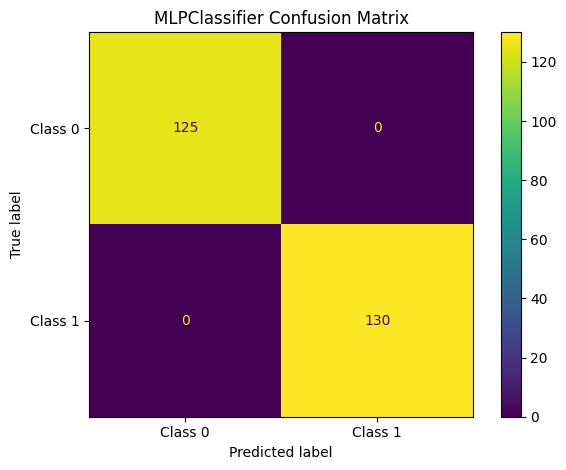

In [73]:
# ==========================================================
# 38. Confusion matrix for MLPClassifier
# ==========================================================

cm_mlp = confusion_matrix(
    y_test,
    mlp_predictions,
    labels=[-1, 1],
)

display_mlp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mlp,
    display_labels=["Class 0", "Class 1"],
)

display_mlp.plot()
plt.title("MLPClassifier Confusion Matrix")
plt.tight_layout()
plt.show()

In [74]:
# ==========================================================
# 39. Compare all models
# ==========================================================

all_models_comparison = pd.DataFrame({
    "Manual pocket": pocket_metrics,
    "Manual final epoch": final_metrics,
    "scikit-learn Perceptron": metric_summary(y_test, sk_predictions),
    "scikit-learn MLPClassifier": mlp_metrics,
}).T

print("Comparison of all models:")
print(all_models_comparison.round(4).to_string())

Comparison of all models:
                            Accuracy  Precision  Recall      F1
Manual pocket                 0.9922     1.0000  0.9846  0.9922
Manual final epoch            0.9922     1.0000  0.9846  0.9922
scikit-learn Perceptron       0.9804     0.9771  0.9846  0.9808
scikit-learn MLPClassifier    1.0000     1.0000  1.0000  1.0000


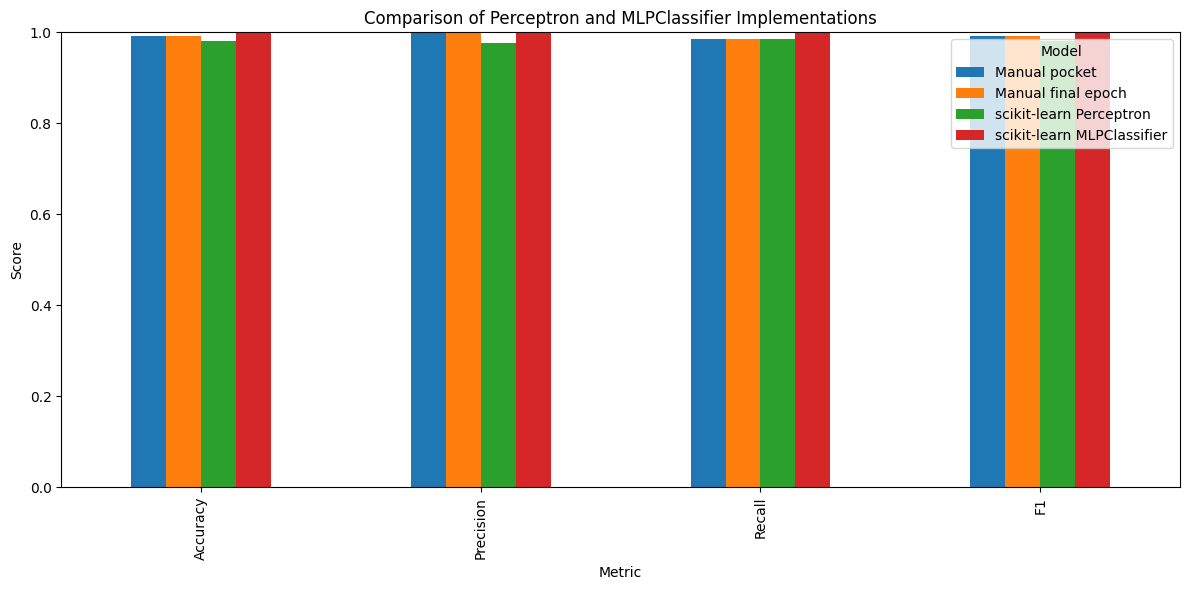

In [75]:
# ==========================================================
# 40. Visual 18: All models comparison
# ==========================================================

all_models_comparison.T.plot(kind="bar", figsize=(12, 6))
plt.ylim(0, 1)
plt.title("Comparison of Perceptron and MLPClassifier Implementations")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.legend(title="Model")
plt.tight_layout()
plt.show()